# Computational Cost vs. Search Space Size

This notebook measures how execution time grows as the design space (number of
combinations of `PMU_ETA_VALUES`, `PANEL_AREAS_M2`, and `BATTERY_SPECS`) increases.

A fixed irradiance dataset (Quito) is reused across all experiments so that
only the combinatorial dimension changes.

In [1]:
import time
import copy
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from simulator import Config, Simulator, BatterySpec
import jinja2

## 0 — System information

Print hardware and software details so that timing results can be reproduced
and compared across different machines.

In [2]:
import sys, os, platform, subprocess, datetime

SEP = "=" * 60

# ── Timestamp ────────────────────────────────────────────────────────────────
print(SEP)
print(f"Run timestamp : {datetime.datetime.now().isoformat(timespec='seconds')}")
print(SEP)

# ── OS / kernel ──────────────────────────────────────────────────────────────
print(f"OS            : {platform.system()} {platform.release()} ({platform.version()})")
print(f"Machine       : {platform.machine()}")

# ── CPU ──────────────────────────────────────────────────────────────────────
try:
    import psutil
    cpu_freq = psutil.cpu_freq()
    freq_str = f"{cpu_freq.max:.0f} MHz max" if cpu_freq else "unknown"
    ram_gb   = psutil.virtual_memory().total / 1024**3
    print(f"CPU logical   : {psutil.cpu_count(logical=True)} cores  ({freq_str})")
    print(f"CPU physical  : {psutil.cpu_count(logical=False)} cores")
    print(f"RAM           : {ram_gb:.1f} GiB")
except ModuleNotFoundError:
    # psutil not installed — fall back to /proc (Linux only)
    try:
        cpu_info = open("/proc/cpuinfo").read()
        model    = next((l.split(":")[1].strip() for l in cpu_info.splitlines()
                         if l.startswith("model name")), "unknown")
        n_cores  = cpu_info.count("processor\t:")
        mem_kb   = int(next((l.split()[1] for l in open("/proc/meminfo")
                             if l.startswith("MemTotal")), "0"))
        print(f"CPU           : {model} ({n_cores} logical cores)")
        print(f"RAM           : {mem_kb / 1024**2:.1f} GiB")
    except Exception:
        print("CPU / RAM     : unavailable (install psutil for details)")

# ── Python & key libraries ───────────────────────────────────────────────────
print(SEP)
print(f"Python        : {sys.version}")
print(f"NumPy         : {np.__version__}")
print(f"Pandas        : {pd.__version__}")

try:
    import numba
    print(f"Numba         : {numba.__version__}")
except ModuleNotFoundError:
    print("Numba         : not installed (pure-Python fallback active)")

try:
    import matplotlib
    print(f"Matplotlib    : {matplotlib.__version__}")
except ModuleNotFoundError:
    pass

# ── Git commit ───────────────────────────────────────────────────────────────
print(SEP)
try:
    git_hash   = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"],
        stderr=subprocess.DEVNULL, text=True
    ).strip()
    git_branch = subprocess.check_output(
        ["git", "rev-parse", "--abbrev-ref", "HEAD"],
        stderr=subprocess.DEVNULL, text=True
    ).strip()
    git_dirty  = subprocess.call(
        ["git", "diff", "--quiet"],
        stderr=subprocess.DEVNULL
    ) != 0
    dirty_tag  = " (dirty)" if git_dirty else ""
    print(f"Git commit    : {git_hash}{dirty_tag}  [{git_branch}]")
except Exception:
    print("Git commit    : unavailable")

Run timestamp : 2026-03-18T17:39:01
OS            : Linux 6.1.0-43-amd64 (#1 SMP PREEMPT_DYNAMIC Debian 6.1.162-1 (2026-02-08))
Machine       : x86_64
CPU logical   : 8 cores  (3900 MHz max)
CPU physical  : 4 cores
RAM           : 31.3 GiB
Python        : 3.13.12 (main, Feb  4 2026, 15:06:39) [GCC 15.2.0]
NumPy         : 2.3.4
Pandas        : 2.3.3
Numba         : 0.63.1
Matplotlib    : 3.10.7
Git commit    : 6f548df (dirty)  [master]


## 1 — Load irradiance data once

The irradiance data is loaded a single time and reused for every experiment,
so that loading time does not contaminate the measurements.

In [3]:
BASE_CONFIG = Config()
BASE_SIM    = Simulator(BASE_CONFIG)

IRRADIANCE_FILE = "raw-data/Quito.csv"
irr_data = BASE_SIM.load_irradiance_data(IRRADIANCE_FILE)

print(f"Irradiance dataset: {len(irr_data):,} hourly records")

Irradiance dataset: 8,760 hourly records


## 2 — Design-space experiment grid

We define progressively larger subsets of each dimension by taking the
first *k* elements of the full lists defined in `Config`.  
The total number of configurations is the Cartesian product
`n_panels × n_batteries × n_pmu`.

In [4]:
# Full dimension lists from the default Config
ALL_PMU    = BASE_CONFIG.PMU_ETA_VALUES   # 8 values
ALL_PANELS = BASE_CONFIG.PANEL_AREAS_M2   # 19 values
ALL_BATT   = BASE_CONFIG.BATTERY_SPECS    # 22 values

print(f"Full space: {len(ALL_PMU)} PMU × {len(ALL_PANELS)} panels × {len(ALL_BATT)} batteries "
      f"= {len(ALL_PMU)*len(ALL_PANELS)*len(ALL_BATT):,} configurations")

# -------------------------------------------------------------------
# Experiment sweep: (n_pmu, n_panels, n_batteries)
# -------------------------------------------------------------------
# We sample a range of sizes for each dimension and take their
# Cartesian product to create the experiment grid.
# -------------------------------------------------------------------
PMU_SIZES    = list(range(1, len(ALL_PMU)    + 1, 2))  # 1,3,5,7 ...
PANEL_SIZES  = list(range(1, len(ALL_PANELS) + 1, 3))  # 1,4,7,10,...
BATT_SIZES   = list(range(1, len(ALL_BATT)   + 1, 4))  # 1,5,9,13,...

experiments = list(itertools.product(PMU_SIZES, PANEL_SIZES, BATT_SIZES))

print(f"\nExperiment grid: {len(experiments)} combinations")
print(f"  PMU sizes    : {PMU_SIZES}")
print(f"  Panel sizes  : {PANEL_SIZES}")
print(f"  Battery sizes: {BATT_SIZES}")

Full space: 8 PMU × 19 panels × 22 batteries = 3,344 configurations

Experiment grid: 168 combinations
  PMU sizes    : [1, 3, 5, 7]
  Panel sizes  : [1, 4, 7, 10, 13, 16, 19]
  Battery sizes: [1, 5, 9, 13, 17, 21]


## 3 — Run simulations and record timing

For each combination of dimension sizes we:
1. Build a custom `Config` with the appropriate subsets.
2. Run the full simulation pipeline (PV → balance → SoC → viability).
3. Record wall-clock time.

> **Note:** The Numba `@njit` kernel is JIT-compiled on the first call;  
> we run a warm-up pass first so timings are not inflated by compilation.

In [5]:
# ─── Numba warm-up (compile the JIT kernel before we start timing) ───────────
print("Warming up Numba JIT kernel ...")
_warmup_config = copy.copy(BASE_CONFIG)
_warmup_config.PANEL_AREAS_M2 = ALL_PANELS[:1]
_warmup_config.BATTERY_SPECS  = ALL_BATT[:1]
_warmup_config.PMU_ETA_VALUES  = ALL_PMU[:1]
_warmup_sim = Simulator(_warmup_config)
_df_pv   = _warmup_sim.compute_pv_power(irr_data)
_df_bal  = _warmup_sim.compute_hourly_balance(_df_pv)
_df_soc  = _warmup_sim.simulate_battery_soc(_df_bal)
print("Warm-up done.\n")

# ─── Main timing loop ─────────────────────────────────────────────────────────
results = []

for idx, (n_pmu, n_panels, n_batt) in enumerate(experiments):
    n_configs = n_pmu * n_panels * n_batt

    # Build a config for this experiment
    cfg = copy.copy(BASE_CONFIG)
    cfg.PMU_ETA_VALUES  = ALL_PMU[:n_pmu]
    cfg.PANEL_AREAS_M2  = ALL_PANELS[:n_panels]
    cfg.BATTERY_SPECS   = ALL_BATT[:n_batt]

    sim = Simulator(cfg)

    # --- Time each stage separately, then compute total ---
    t0 = time.perf_counter()
    df_pv  = sim.compute_pv_power(irr_data)
    t_pv   = time.perf_counter() - t0

    t0 = time.perf_counter()
    df_bal = sim.compute_hourly_balance(df_pv)
    t_bal  = time.perf_counter() - t0

    t0 = time.perf_counter()
    df_soc = sim.simulate_battery_soc(df_bal)
    t_soc  = time.perf_counter() - t0

    t0 = time.perf_counter()
    summary = sim.evaluate_viability(df_soc)
    t_eval  = time.perf_counter() - t0

    t_total = t_pv + t_bal + t_soc + t_eval

    results.append({
        "n_pmu":      n_pmu,
        "n_panels":   n_panels,
        "n_batteries":n_batt,
        "n_configs":  n_configs,
        "t_pv_s":     t_pv,
        "t_balance_s":t_bal,
        "t_soc_s":    t_soc,
        "t_viability_s":t_eval,
        "t_total_s":  t_total,
    })

    if (idx + 1) % 20 == 0 or idx == 0:
        print(f"  [{idx+1:3d}/{len(experiments)}] "
              f"pmu={n_pmu:2d} panels={n_panels:2d} batt={n_batt:2d} "
              f"→ {n_configs:5,} configs   t={t_total:.3f}s")

df_results = pd.DataFrame(results)
print(f"\nDone — {len(df_results)} experiments completed.")

Warming up Numba JIT kernel ...
Warm-up done.

  [  1/168] pmu= 1 panels= 1 batt= 1 →     1 configs   t=0.031s
  [ 20/168] pmu= 1 panels=10 batt= 5 →    50 configs   t=0.504s
  [ 40/168] pmu= 1 panels=19 batt=13 →   247 configs   t=2.414s
  [ 60/168] pmu= 3 panels= 7 batt=21 →   441 configs   t=4.307s
  [ 80/168] pmu= 3 panels=19 batt= 5 →   285 configs   t=2.762s
  [100/168] pmu= 5 panels= 7 batt=13 →   455 configs   t=4.265s
  [120/168] pmu= 5 panels=16 batt=21 → 1,680 configs   t=16.999s
  [140/168] pmu= 7 panels= 7 batt= 5 →   245 configs   t=2.165s
  [160/168] pmu= 7 panels=16 batt=13 → 1,456 configs   t=14.736s

Done — 168 experiments completed.


## 4 — Results overview

In [6]:
df_results.sort_values("n_configs", inplace=True)
df_results.reset_index(drop=True, inplace=True)

# Show summary table
display_cols = ["n_pmu", "n_panels", "n_batteries", "n_configs",
                "t_pv_s", "t_balance_s", "t_soc_s", "t_viability_s", "t_total_s"]
df_results[display_cols].style \
    .background_gradient(subset=["t_total_s"], cmap="YlOrRd") \
    .format({
        "n_configs":     "{:,}",
        "t_pv_s":        "{:.4f}s",
        "t_balance_s":   "{:.4f}s",
        "t_soc_s":       "{:.4f}s",
        "t_viability_s": "{:.4f}s",
        "t_total_s":     "{:.4f}s",
    })

,n_pmu,n_panels,n_batteries,n_configs,t_pv_s,t_balance_s,t_soc_s,t_viability_s,t_total_s
0,1,1,1,1,0.0038s,0.0024s,0.0138s,0.0111s,0.0311s
1,3,1,1,3,0.0031s,0.0041s,0.0227s,0.0186s,0.0485s
2,1,4,1,4,0.0054s,0.0031s,0.0265s,0.0203s,0.0553s
3,1,1,5,5,0.0033s,0.0025s,0.0370s,0.0215s,0.0642s
4,5,1,1,5,0.0034s,0.0066s,0.0390s,0.0220s,0.0710s
5,1,7,1,7,0.0080s,0.0042s,0.0441s,0.0269s,0.0833s
6,7,1,1,7,0.0054s,0.0095s,0.0778s,0.0279s,0.1207s
7,1,1,9,9,0.0030s,0.0020s,0.0606s,0.0323s,0.0979s
8,1,10,1,10,0.0100s,0.0053s,0.0600s,0.0363s,0.1116s
9,3,4,1,12,0.0055s,0.0078s,0.0718s,0.0456s,0.1308s


## 5 — Visualization

### 5.1 Total time vs. number of configurations

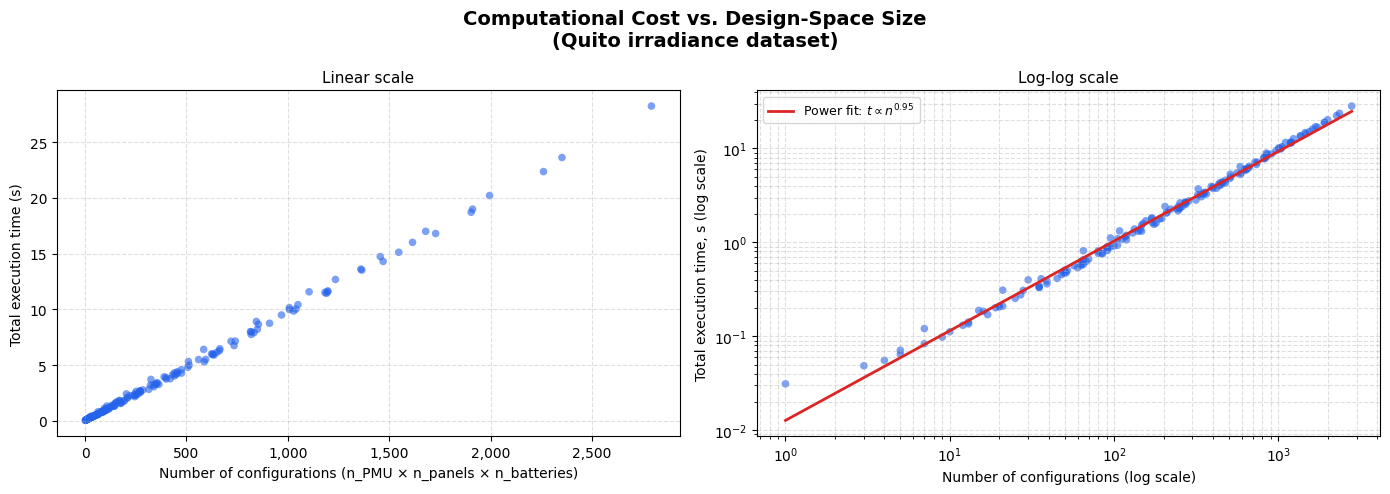

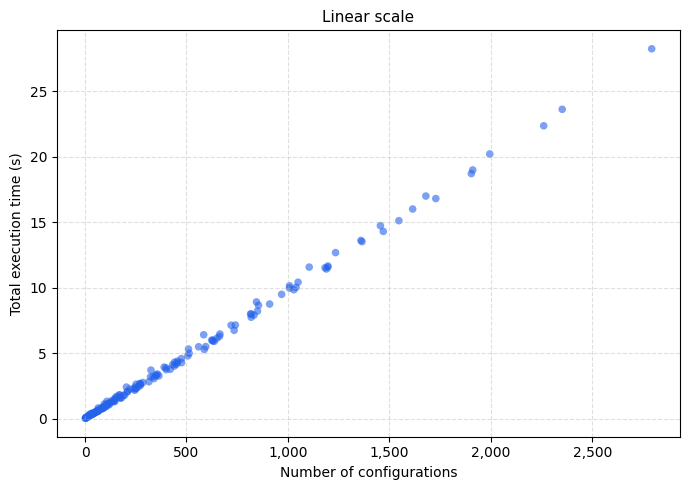

Power-law fit: t = 1.2707e-02 × n^0.955


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Computational Cost vs. Design-Space Size\n(Quito irradiance dataset)",
             fontsize=14, fontweight="bold")

color = "#2563EB"

# ── Left: linear scale ──────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(df_results["n_configs"], df_results["t_total_s"],
           alpha=0.6, s=30, color=color, edgecolors="none")
ax.set_xlabel("Number of configurations (n_PMU × n_panels × n_batteries)", fontsize=10)
ax.set_ylabel("Total execution time (s)", fontsize=10)
ax.set_title("Linear scale", fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(True, linestyle="--", alpha=0.4)

# ── Right: log-log scale ─────────────────────────────────────────────────────
ax = axes[1]
ax.scatter(df_results["n_configs"], df_results["t_total_s"],
           alpha=0.6, s=30, color=color, edgecolors="none")

# Fit a power-law regression: log(t) = a + b*log(n)
mask = df_results["n_configs"] > 0
log_n = np.log(df_results.loc[mask, "n_configs"].values)
log_t = np.log(df_results.loc[mask, "t_total_s"].values)
coeffs = np.polyfit(log_n, log_t, 1)
b, log_a = coeffs
a = np.exp(log_a)

x_fit = np.linspace(df_results["n_configs"].min(), df_results["n_configs"].max(), 300)
ax.plot(x_fit, a * x_fit**b, color="#DC2626", lw=2, label=f"Power fit: $t \\propto n^{{{b:.2f}}}$")
ax.legend(fontsize=9)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of configurations (log scale)", fontsize=10)
ax.set_ylabel("Total execution time, s (log scale)", fontsize=10)
ax.set_title("Log-log scale", fontsize=11)
ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("computation-cost.png", dpi=150, bbox_inches="tight")

# Save only the linear chart as PDF
fig_linear, ax_linear = plt.subplots(figsize=(7, 5))
ax_linear.scatter(df_results["n_configs"], df_results["t_total_s"],
                  alpha=0.6, s=30, color=color, edgecolors="none")
ax_linear.set_xlabel("Number of configurations", fontsize=10)
ax_linear.set_ylabel("Total execution time (s)", fontsize=10)
ax_linear.set_title("Linear scale", fontsize=11)
ax_linear.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax_linear.grid(True, linestyle="--", alpha=0.4)
fig_linear.tight_layout()
fig_linear.savefig("computation-cost.pdf", bbox_inches="tight")

plt.show()
print(f"Power-law fit: t = {a:.4e} × n^{b:.3f}")

### 5.2 Time breakdown by pipeline stage

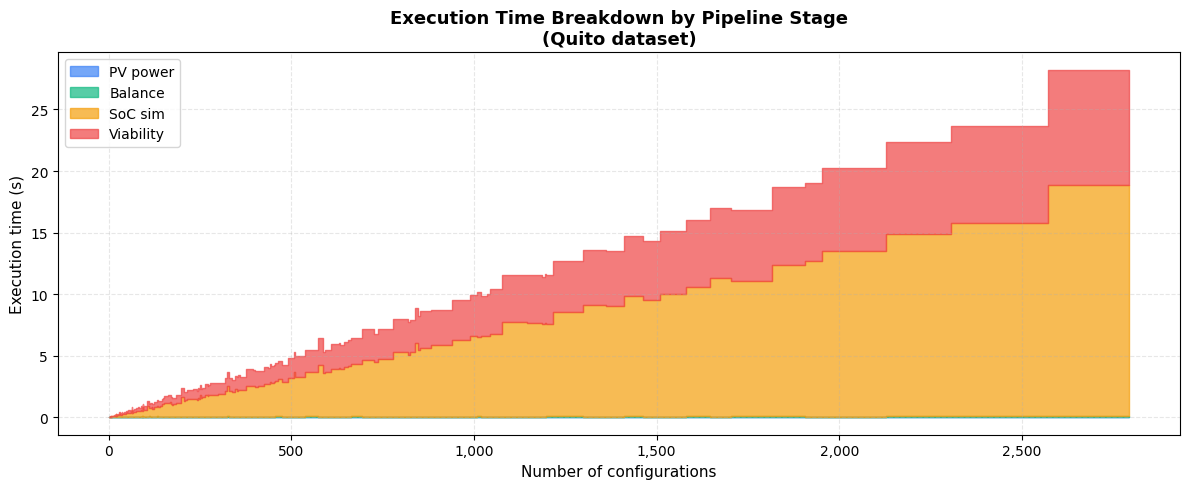

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

stages = {
    "PV power":   ("t_pv_s",         "#3B82F6"),
    "Balance":    ("t_balance_s",     "#10B981"),
    "SoC sim":    ("t_soc_s",         "#F59E0B"),
    "Viability":  ("t_viability_s",   "#EF4444"),
}

x = df_results["n_configs"].values
bottoms = np.zeros(len(df_results))

for label, (col, clr) in stages.items():
    heights = df_results[col].values
    ax.fill_between(x, bottoms, bottoms + heights,
                    label=label, color=clr, alpha=0.7, step="mid")
    bottoms += heights

ax.set_xlabel("Number of configurations", fontsize=11)
ax.set_ylabel("Execution time (s)", fontsize=11)
ax.set_title("Execution Time Breakdown by Pipeline Stage\n(Quito dataset)",
             fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(loc="upper left", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("computation-cost-breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.3 Heat maps — time vs. pairs of dimensions

Each cell shows the total execution time for the **maximum value of the third
dimension**, so we can see how scale in each individual axis affects cost.

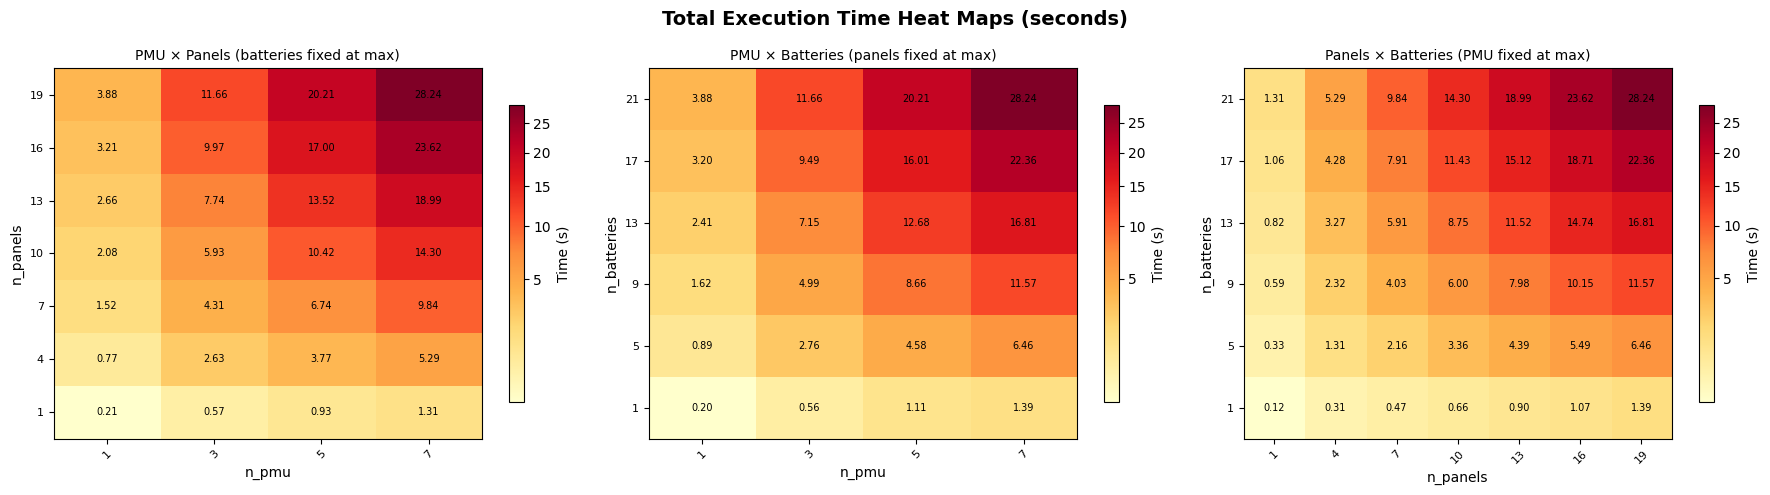

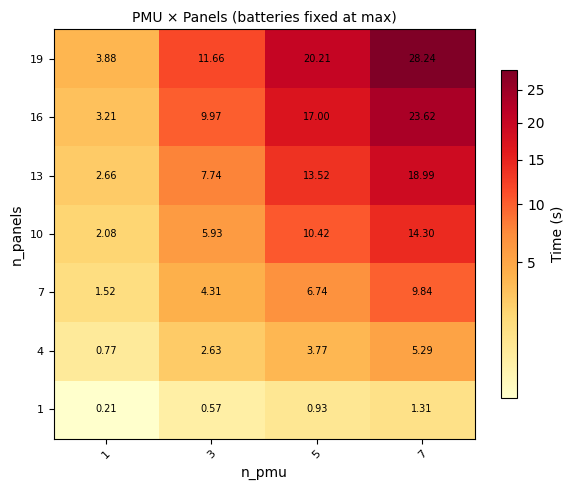

In [9]:
import matplotlib.colors as mcolors

MAX_PMU   = max(PMU_SIZES)
MAX_PANEL = max(PANEL_SIZES)
MAX_BATT  = max(BATT_SIZES)

heatmap_configs = [
    # (title, x_dim, y_dim, fixed_dim, fixed_val)
    ("PMU × Panels (batteries fixed at max)",
     "n_pmu", "n_panels", "n_batteries", MAX_BATT),
    ("PMU × Batteries (panels fixed at max)",
     "n_pmu", "n_batteries", "n_panels", MAX_PANEL),
    ("Panels × Batteries (PMU fixed at max)",
     "n_panels", "n_batteries", "n_pmu", MAX_PMU),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Total Execution Time Heat Maps (seconds)", fontsize=14, fontweight="bold")

for ax, (title, xdim, ydim, fixed_dim, fixed_val) in zip(axes, heatmap_configs):
    subset = df_results[df_results[fixed_dim] == fixed_val].copy()

    # Pivot
    pivot = subset.pivot_table(index=ydim, columns=xdim, values="t_total_s")

    im = ax.imshow(pivot.values, aspect="auto",
                   cmap="YlOrRd", origin="lower",
                   norm=mcolors.PowerNorm(gamma=0.5,
                                          vmin=pivot.values.min(),
                                          vmax=pivot.values.max()))

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=8, rotation=45)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_xlabel(xdim, fontsize=10)
    ax.set_ylabel(ydim, fontsize=10)
    ax.set_title(title, fontsize=10)

    # Annotate cells
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=7, color="black")

    plt.colorbar(im, ax=ax, shrink=0.8, label="Time (s)")

plt.tight_layout()
plt.savefig("computation-cost-heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

# Save the left subplot (PMU × Panels) as a standalone PDF
title_l, xdim_l, ydim_l, fixed_dim_l, fixed_val_l = heatmap_configs[0]
subset_l = df_results[df_results[fixed_dim_l] == fixed_val_l].copy()
pivot_l = subset_l.pivot_table(index=ydim_l, columns=xdim_l, values="t_total_s")
fig_l, ax_l = plt.subplots(figsize=(6, 5))
im_l = ax_l.imshow(pivot_l.values, aspect="auto",
                    cmap="YlOrRd", origin="lower",
                    norm=mcolors.PowerNorm(gamma=0.5,
                                           vmin=pivot_l.values.min(),
                                           vmax=pivot_l.values.max()))
ax_l.set_xticks(range(len(pivot_l.columns)))
ax_l.set_xticklabels(pivot_l.columns, fontsize=8, rotation=45)
ax_l.set_yticks(range(len(pivot_l.index)))
ax_l.set_yticklabels(pivot_l.index, fontsize=8)
ax_l.set_xlabel(xdim_l, fontsize=10)
ax_l.set_ylabel(ydim_l, fontsize=10)
ax_l.set_title(title_l, fontsize=10)
for i in range(pivot_l.shape[0]):
    for j in range(pivot_l.shape[1]):
        val = pivot_l.values[i, j]
        if not np.isnan(val):
            ax_l.text(j, i, f"{val:.2f}", ha="center", va="center",
                      fontsize=7, color="black")
plt.colorbar(im_l, ax=ax_l, shrink=0.8, label="Time (s)")
plt.tight_layout()
plt.savefig("computation-cost-left.pdf", bbox_inches="tight")
plt.show()

## 6 — Key statistics

In [10]:
# Stage fractions at max search space
worst = df_results.loc[df_results["n_configs"].idxmax()]
print("=" * 55)
print(f"Largest experiment: {int(worst['n_configs']):,} configurations")
print(f"  n_PMU={int(worst['n_pmu'])},  n_panels={int(worst['n_panels'])},  n_batteries={int(worst['n_batteries'])}")
print(f"  Total time: {worst['t_total_s']:.3f} s")
print()
total = worst["t_total_s"]
for stage, (col, _) in stages.items():
    frac = worst[col] / total * 100
    print(f"  {stage:<14s}: {worst[col]:.4f} s  ({frac:.1f}%)")

print()
print(f"Power-law fit:  t = {a:.4e} × n^{b:.3f}")
print(f"  → scaling exponent ≈ {b:.2f}  (ideal linear = 1.0)")
print("=" * 55)

Largest experiment: 2,793 configurations
  n_PMU=7,  n_panels=19,  n_batteries=21
  Total time: 28.242 s

  PV power      : 0.0179 s  (0.1%)
  Balance       : 0.0816 s  (0.3%)
  SoC sim       : 18.8036 s  (66.6%)
  Viability     : 9.3390 s  (33.1%)

Power-law fit:  t = 1.2707e-02 × n^0.955
  → scaling exponent ≈ 0.95  (ideal linear = 1.0)
